# Sanity check — errores en test set

Análisis cualitativo y cuantitativo de clasificaciones incorrectas con los mejores modelos (`models/temas`, `models/carga-phase3`).

Equivalente a `python scripts/show_misclassified.py`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / "config.yml").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

# Evita ImportError si el kernel importó mindful_news antes de editar el código
import importlib
import mindful_news.training.data as _data
import mindful_news.training.evaluate as _evaluate
import mindful_news.training.preprocess as _preprocess

importlib.reload(_preprocess)
importlib.reload(_data)
importlib.reload(_evaluate)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 110

from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

from mindful_news.training.evaluate import _default_model_dir, predict_test_errors

TASKS = ["temas", "carga"]
results = {}
for task in TASKS:
    frame = predict_test_errors(task)
    results[task] = frame
    errors = (~frame["correct"]).sum()
    print(f"{task}: {errors}/{len(frame)} errores ({errors/len(frame):.1%}) | model={_default_model_dir(task)}")


c:\Users\arihs\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
c:\Users\arihs\anaconda3\lib\site-packages\torchvision\io\image.py:13: UserWarning: Failed to load image Python extension: 'Could not load this library: C:\Users\arihs\anaconda3\Lib\site-packages\torchvision\image.pyd'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


Loading weights:   0%|          | 0/138 [00:00<?, ?it/s]

temas: 444/1801 errores (24.7%) | model=C:\Users\arihs\Code\mlprod-obligatorio\models\temas


Loading weights:   0%|          | 0/138 [00:00<?, ?it/s]

carga: 353/1801 errores (19.6%) | model=C:\Users\arihs\Code\mlprod-obligatorio\models\carga-phase3


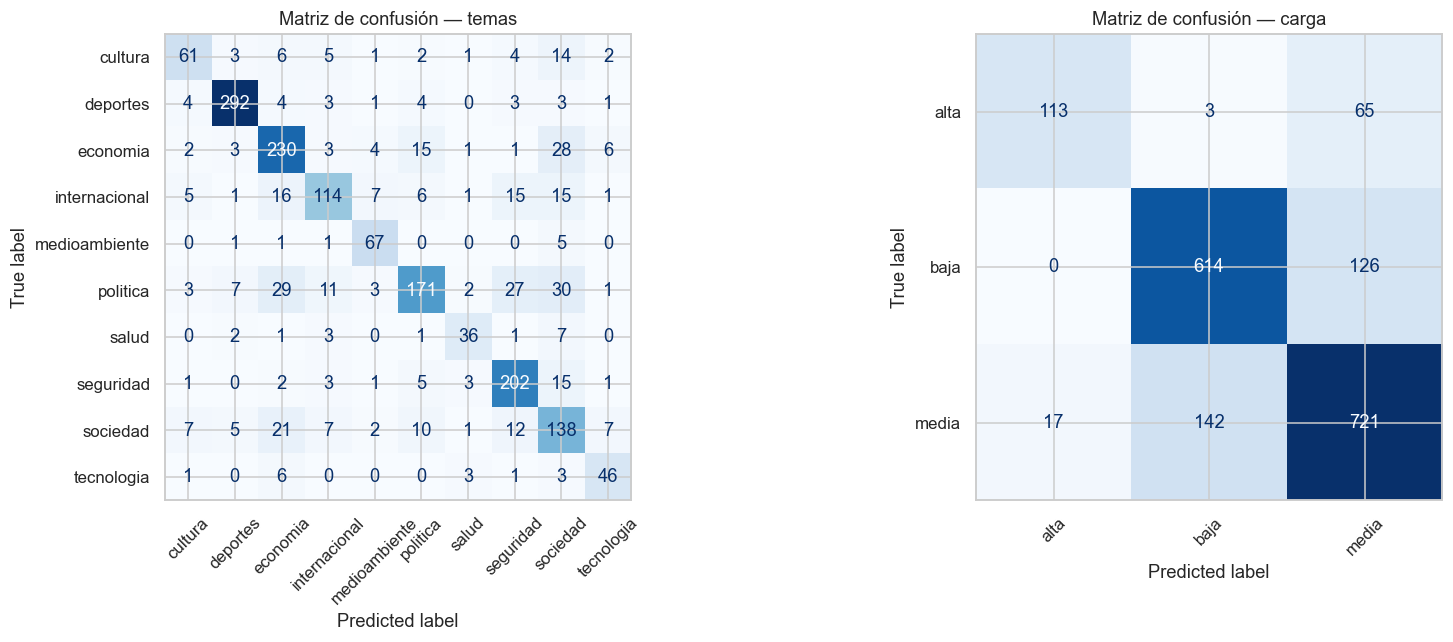

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, task in zip(axes, TASKS):
    frame = results[task]
    labels = sorted(frame["true_label"].unique())
    cm = confusion_matrix(frame["true_label"], frame["pred_label"], labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=False)
    ax.set_title(f"Matriz de confusión — {task}")

plt.tight_layout()
plt.show()


In [3]:
def top_confusion_pairs(frame: pd.DataFrame, n: int = 10) -> pd.DataFrame:
    errors = frame[~frame["correct"]]
    pairs = (
        errors.groupby(["true_label", "pred_label"])
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
    )
    return pairs.head(n)


for task in TASKS:
    print(f"\n=== {task.upper()} — pares más frecuentes ===")
    display(top_confusion_pairs(results[task]))



=== TEMAS — pares más frecuentes ===


,true_label,pred_label,count
46,politica,sociedad,30
41,politica,economia,29
24,economia,sociedad,28
45,politica,seguridad,27
64,sociedad,economia,21
28,internacional,economia,16
21,economia,politica,15
60,seguridad,sociedad,15
33,internacional,sociedad,15
32,internacional,seguridad,15



=== CARGA — pares más frecuentes ===


,true_label,pred_label,count
4,media,baja,142
2,baja,media,126
1,alta,media,65
3,media,alta,17
0,alta,baja,3


c:\Users\arihs\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\arihs\anaconda3\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\arihs\anaconda3\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\arihs\anaconda3\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a len

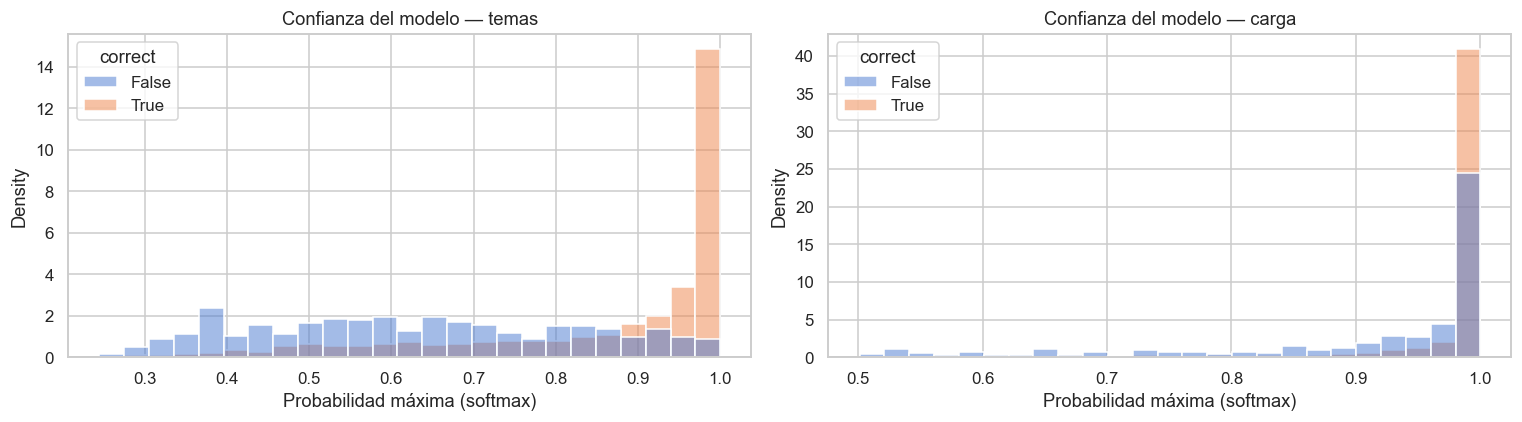

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, task in zip(axes, TASKS):
    frame = results[task]
    sns.histplot(
        data=frame,
        x="confidence",
        hue="correct",
        bins=25,
        stat="density",
        common_norm=False,
        ax=ax,
    )
    ax.set_title(f"Confianza del modelo — {task}")
    ax.set_xlabel("Probabilidad máxima (softmax)")

plt.tight_layout()
plt.show()


In [5]:
def show_examples(frame: pd.DataFrame, n: int = 8) -> pd.DataFrame:
    errors = frame[~frame["correct"]].head(n)
    cols = ["true_label", "pred_label", "confidence", "medio", "split_date", "titulo", "url"]
    return errors[cols]


for task in TASKS:
    print(f"\n=== {task.upper()} — ejemplos mal clasificados (alta confianza) ===")
    display(show_examples(results[task]))



=== TEMAS — ejemplos mal clasificados (alta confianza) ===


,true_label,pred_label,confidence,medio,split_date,titulo,url
1580,politica,deportes,0.998479,El Observador,2026-06-04 10:08:00,Elecciones en el Real Madrid: Riquelme promete...,https://www.elobservador.com.uy/espana/relax/e...
307,politica,sociedad,0.994410,El Observador,2026-05-28 08:19:00,Diputado colorado propuso usar cuarteles para ...,https://www.elobservador.com.uy/nacional/diput...
457,sociedad,tecnologia,0.994198,El Observador,2026-05-29 00:00:00,La carpintera que venció a la inteligencia art...,https://www.elobservador.com.uy/argentina/soci...
1556,economia,deportes,0.991663,El Observador,2026-06-04 09:10:00,Reventa mundialista: piden fortunas por palcos...,https://www.elobservador.com.uy/espana/economi...
274,economia,tecnologia,0.985583,El Observador,2026-05-28 00:00:00,Dos hermanos argentinos crearon una fintech pa...,https://www.elobservador.com.uy/argentina/econ...
550,sociedad,economia,0.985274,Montevideo Portal,2026-05-29 12:14:00,Llamado laboral en el Mides con sueldo de $ 11...,https://www.montevideo.com.uy/Noticias/Llamado...
436,sociedad,seguridad,0.984497,El Observador,2026-05-28 20:37:00,"Encuesta de Equipos muestra ""incremento signif...",https://www.elobservador.com.uy/nacional/hubo-...
13,seguridad,cultura,0.982252,El Observador,2026-05-26 13:56:00,Con exhibiciones de Masha y el oso y ¿Quién so...,https://www.elobservador.com.uy/nacional/con-e...



=== CARGA — ejemplos mal clasificados (alta confianza) ===


,true_label,pred_label,confidence,medio,split_date,titulo,url
832,media,baja,0.999999,La Diaria,2026-06-01 00:00:00,El Fondo Nacional de Recursos como fondo marca...,https://ladiaria.com.uy/economia/articulo/2026...
932,baja,media,0.999999,El Observador,2026-06-01 05:00:00,La economía de 2026 pisa el freno: expertos co...,https://www.elobservador.com.uy/economia-y-emp...
443,baja,media,0.999999,Montevideo Portal,2026-05-28 21:15:00,Principales problemas de la ciudadanía: más de...,https://www.montevideo.com.uy/Noticias/Princip...
552,media,baja,0.999999,El Observador,2026-05-29 12:19:00,La línea G de Coetc dejará de existir y recupe...,https://www.elobservador.com.uy/nacional/la-li...
701,baja,media,0.999999,El Observador,2026-05-30 16:54:00,"""Cuando hay descuentos yo me tiro de cabeza"", ...",https://www.elobservador.com.uy/nacional/cuand...
1306,media,baja,0.999998,La Diaria,2026-06-03 10:11:07,Horacio Merlo: “La cultura siempre es la cenic...,https://ladiaria.com.uy/paysandu/articulo/2026...
140,baja,media,0.999996,Montevideo Portal,2026-05-27 09:37:00,DGI refuerza controles a contribuyentes de IRA...,https://www.montevideo.com.uy/Noticias/DGI-ref...
249,baja,media,0.999992,El Observador,2026-05-27 20:05:00,Los coches eléctricos ya rozan el 70% del merc...,https://www.elobservador.com.uy/espana/economi...


In [6]:
# Errores con baja confianza (el modelo duda)
LOW_CONF = 0.55

for task in TASKS:
    frame = results[task]
    borderline = frame[(~frame["correct"]) & (frame["confidence"] < LOW_CONF)].sort_values("confidence")
    print(f"\n{task}: {len(borderline)} errores con confianza < {LOW_CONF}")
    if not borderline.empty:
        display(borderline[["true_label", "pred_label", "confidence", "titulo"]].head(8))



temas: 168 errores con confianza < 0.55


,true_label,pred_label,confidence,titulo
1081,politica,deportes,0.264294,Karina Milei y Martín Menem prohíben a los lib...
893,seguridad,politica,0.264843,martin mutio amplio la denuncia contra monica ...
187,cultura,sociedad,0.276492,Reforma de la Biblioteca Nacional: así es el p...
438,politica,economia,0.285046,“Error de comunicación”: Arim negó asignación ...
1304,cultura,tecnologia,0.286907,'Backrooms': Llega a España el terror más taqu...
118,politica,seguridad,0.291660,"Contralmirante Musso: Cardama tenía ""alarmas"" ..."
100,politica,sociedad,0.298985,La trama secreta de la tregua libertaria
1555,internacional,cultura,0.304389,Madrid: Plaza de Cibeles está lista para la mi...



carga: 14 errores con confianza < 0.55


,true_label,pred_label,confidence,titulo
529,baja,media,0.501150,¿Por qué se calienta el cargador del celular y...
5,media,alta,0.513862,"Niño de seis años cruzaba por una cebra, fue a..."
1383,baja,media,0.520435,Fiscalía de Milán ratificó el indulto a la ita...
1155,alta,media,0.523771,"Brasil: mujer y niño, víctimas de tiburones en..."
545,media,baja,0.528847,La Casa Blanca lanza una web que presenta a lo...
222,media,baja,0.531741,Termómetro electoral en Texas: el candidato de...
1692,baja,media,0.533204,"El país que no tiene capital, vende su naciona..."
1693,baja,media,0.533204,"El país que no tiene capital, vende su naciona..."


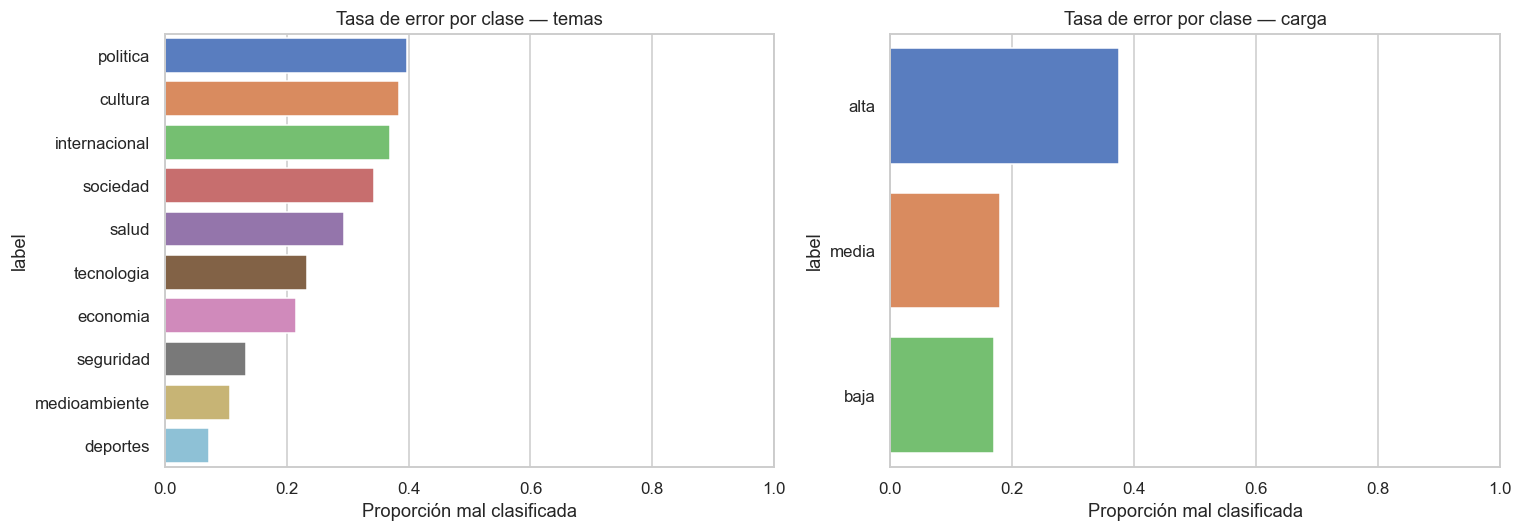

In [7]:
# Tasa de error por etiqueta verdadera
rows = []
for task, frame in results.items():
    for label, group in frame.groupby("true_label"):
        err_rate = (~group["correct"]).mean()
        rows.append({"task": task, "label": label, "error_rate": err_rate, "support": len(group)})

error_by_label = pd.DataFrame(rows)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, task in zip(axes, TASKS):
    subset = error_by_label[error_by_label["task"] == task].sort_values("error_rate", ascending=False)
    sns.barplot(data=subset, x="error_rate", y="label", ax=ax, orient="h")
    ax.set_xlim(0, 1)
    ax.set_title(f"Tasa de error por clase — {task}")
    ax.set_xlabel("Proporción mal clasificada")

plt.tight_layout()
plt.show()


## Input del modelo: sección + título

Desde la **fase 4 de tuning (temas)** el clasificador ya no ve solo el titular. El texto que entra a mmBERT se arma así:

```
{seccion} | {titulo}
```

Ejemplo real:

> `Noticias, Policiales | Dos veces en dos semanas: balearon casa en Jardines del Hipódromo`

**Por qué:** la sección del medio ayuda a desambiguar temas (`deporte`→deportes, `Noticias, Policiales`→seguridad). En el dataset, **99.98%** de titulares tienen `seccion`; si falta, se usa solo el título.

**Config** (`config.yml` → `training.input`):
- `include_seccion: true`
- `separator: " | "`
- `template: "{seccion}{sep}{titulo}"`

**Tuning fase 4:** 30 trials Optuna solo para **temas**, con anchor del ganador de fase 1. Modelo final en `models/temas-phase4/`. W&B group: `temas-optuna-v4`.

**Compatibilidad:** modelos viejos (solo título) guardan `input_text_mode: titulo` en `metrics.json`; la inferencia respeta eso. Los nuevos guardan `seccion_titulo`.

In [11]:
import importlib
import mindful_news.training.data as data_mod
import mindful_news.training.preprocess as preprocess_mod

importlib.reload(preprocess_mod)
importlib.reload(data_mod)

sample = data_mod.prepare_task_frame(data_mod.load_splits()["test"], "temas").head(5)
sample[["seccion", "titulo", "input_text", "tema"]]

KeyError: "['seccion', 'input_text'] not in index"

In [ ]:
# Comparar fase 1 (solo título) vs fase 4 (sección + título)
import json

phase4_best = ROOT / "data" / "tuning" / "temas_phase4_best.json"
phase1_best = ROOT / "data" / "tuning" / "temas_best.json"

for label, path in [("Fase 1 (solo título)", phase1_best), ("Fase 4 (sección+título)", phase4_best)]:
    if not path.exists():
        print(f"{label}: aún no disponible ({path.name})")
        continue
    best = json.loads(path.read_text(encoding="utf-8"))
    test = best.get("final_test_metrics", {})
    print(
        f"{label} | trial {best.get('trial_number')} | "
        f"val F1={best.get('val_f1_macro', 0):.3f} | "
        f"test F1={test.get('test_f1_macro', 0):.3f}"
    )
    print(f"  model_dir: {best.get('final_model_dir')}")

Fase 1 (solo título) | trial 14 | val F1=0.780 | test F1=0.742
  model_dir: C:\Users\arihs\Code\mlprod-obligatorio\models\temas
Fase 4 (sección+título): aún no disponible (temas_phase4_best.json)
